In [12]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
from pathlib import Path
import pandas as pd

data_dir = Path("../../data")
X_train = pd.read_csv(data_dir / "X_train.csv")
X_test = pd.read_csv(data_dir / "X_test.csv")
y_train = pd.read_csv(data_dir / "y_train.csv").values.ravel()
y_test = pd.read_csv(data_dir / "y_test.csv").values.ravel()

print("Loaded:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

Loaded:
X_train: (217124, 37)
X_test:  (10848, 37)
y_train: (217124,)
y_test:  (10848,)


In [14]:
from src.predictors.predictors import EnsembleLearner
from src.evaluation.evaluate_classifier import evaluate_classifier, print_classifier_results


def print_evaluation(sub_model, X_train, X_test, y_train, y_test):
    sub_model_eval = clone(sub_model)
    sub_model_eval.fit(X_train, y_train)
    results = evaluate_classifier(
        sub_model_eval,
        X_train,
        X_test,
        y_train,
        y_test,
    )
    print_classifier_results(results)

model = EnsembleLearner(meta_test_size=0.15)
print("Initializing model...")

Initializing model...


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

# Add Logistic Regression (Add scaling and L2 regularization)
logistic_regression = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    l1_ratio=0,
    max_iter=10000
)
print_evaluation(logistic_regression, X_train, X_test, y_train, y_test)
model.add_learner("Logistic Regression (L2)", logistic_regression)

Classifier Evaluation
Train games     : 217,124
Test games      : 10,848

Train accuracy  : 71.67%
Test accuracy   : 71.17%

Train log loss  : 0.5429
Test log loss   : 0.5518

Train ROC-AUC   : 0.7968
Test ROC-AUC    : 0.7877

Train confusion matrix:
[[77811 30751]
 [30751 77811]]

Test confusion matrix:
[[3860 1564]
 [1564 3860]]


In [16]:
from lightgbm import LGBMClassifier

# Add LightGBM (The dominant algorithm for Men's data)
lightgbm = LGBMClassifier(
    objective="binary",
    n_estimators=500,
    learning_rate=0.02,
    max_depth=5,
    num_leaves=31,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    verbose=-1,
)
print_evaluation(lightgbm, X_train, X_test, y_train, y_test)
model.add_learner("LightGBM", lightgbm)

Classifier Evaluation
Train games     : 217,124
Test games      : 10,848

Train accuracy  : 72.65%
Test accuracy   : 71.35%

Train log loss  : 0.5290
Test log loss   : 0.5429

Train ROC-AUC   : 0.8086
Test ROC-AUC    : 0.7952

Train confusion matrix:
[[78911 29651]
 [29727 78835]]

Test confusion matrix:
[[3867 1557]
 [1551 3873]]


In [17]:
from xgboost import XGBClassifier

# Add XGBoost (Constrain depth to prevent memorization)
xgboost = XGBClassifier(
    n_estimators=800,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.6,
    colsample_bytree=0.6,
    random_state=42,
)
print_evaluation(xgboost, X_train, X_test, y_train, y_test)
model.add_learner("XGBoost", xgboost)

Classifier Evaluation
Train games     : 217,124
Test games      : 10,848

Train accuracy  : 73.06%
Test accuracy   : 71.19%

Train log loss  : 0.5234
Test log loss   : 0.5428

Train ROC-AUC   : 0.8137
Test ROC-AUC    : 0.7951

Train confusion matrix:
[[79259 29303]
 [29186 79376]]

Test confusion matrix:
[[3865 1559]
 [1566 3858]]


In [18]:
from sklearn.ensemble import RandomForestClassifier

# Add Random Forest
random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=10,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)
print_evaluation(random_forest, X_train, X_test, y_train, y_test)
model.add_learner("Random Forest", random_forest)

Classifier Evaluation
Train games     : 217,124
Test games      : 10,848

Train accuracy  : 76.06%
Test accuracy   : 70.55%

Train log loss  : 0.4907
Test log loss   : 0.5468

Train ROC-AUC   : 0.8486
Test ROC-AUC    : 0.7916

Train confusion matrix:
[[82527 26035]
 [25948 82614]]

Test confusion matrix:
[[3823 1601]
 [1594 3830]]


In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Add KNN classifier
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=35,
        weights="distance",
        metric="minkowski",
        p=2,
    ))
])
print_evaluation(knn, X_train, X_test, y_train, y_test)
model.add_learner("KNN Classifier", knn)

Classifier Evaluation
Train games     : 217,124
Test games      : 10,848

Train accuracy  : 100.00%
Test accuracy   : 70.43%

Train log loss  : 0.0000
Test log loss   : 0.5941

Train ROC-AUC   : 1.0000
Test ROC-AUC    : 0.7759

Train confusion matrix:
[[108562      0]
 [     0 108562]]

Test confusion matrix:
[[3820 1604]
 [1604 3820]]


In [20]:
from sklearn.neural_network import MLPClassifier

# Add Basic Neural Network
mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=1e-3,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        random_state=42,
    ))
])
print_evaluation(mlp, X_train, X_test, y_train, y_test)
model.add_learner("Basic Neural Network", mlp)

Classifier Evaluation
Train games     : 217,124
Test games      : 10,848

Train accuracy  : 72.27%
Test accuracy   : 71.16%

Train log loss  : 0.5356
Test log loss   : 0.5464

Train ROC-AUC   : 0.8034
Test ROC-AUC    : 0.7923

Train confusion matrix:
[[80400 28162]
 [32051 76511]]

Test confusion matrix:
[[3953 1471]
 [1658 3766]]


Partitioning data to prevent leakage...
Training base learners...
Logistic Regression with L2 train=0.7173  test=0.7149
LightGBM             train=0.7283  test=0.7148
XGBoost              train=0.7330  test=0.7151
Random Forest        train=0.7657  test=0.7130
KNN Classifier       train=1.0000  test=0.7025
Basic Neural Network train=0.7278  test=0.7148
Generating meta-features...
Training meta-learner...
Matrix 	ilde{E}^T * 	ilde{E} (Error Correlation):
[[1.     0.8494 0.8549 0.8145 0.2449 0.8111]
 [0.8494 1.     0.9511 0.8838 0.254  0.8353]
 [0.8549 0.9511 1.     0.8933 0.2588 0.8395]
 [0.8145 0.8838 0.8933 1.     0.2867 0.801 ]
 [0.2449 0.254  0.2588 0.2867 1.     0.244 ]
 [0.8111 0.8353 0.8395 0.801  0.244  1.    ]]


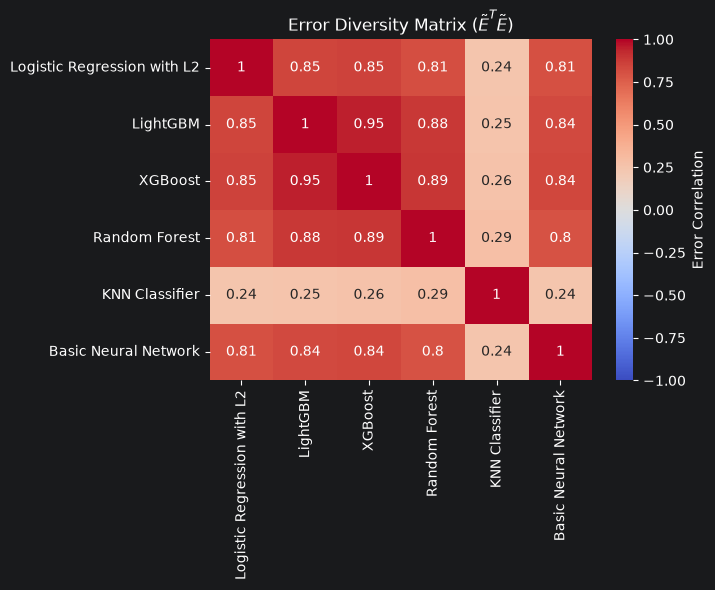

In [21]:
# Train the architecture
model.fit(X_train, y_train)
model.plot_error_heatmap(X_train, y_train)

In [22]:
# Where did we end up
results = evaluate_classifier(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
)
print_classifier_results(results)

Classifier Evaluation
Train games     : 217,124
Test games      : 10,848

Train accuracy  : 70.36%
Test accuracy   : 71.30%

Train log loss  : 0.5679
Test log loss   : 0.5485

Train ROC-AUC   : 0.7775
Test ROC-AUC    : 0.7939

Train confusion matrix:
[[76039 32523]
 [31825 76737]]

Test confusion matrix:
[[3850 1574]
 [1539 3885]]
